In [40]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns

In [2]:
#Read in modeled organics not summed in previous iterations (SOA and POM individually)
df_soa_pom = pd.read_csv('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Daily_Timeseries_NADPsites/DOC_BC_wetdep_Daily_SamplingIntAssigned.csv')
df_soa_pom

,Unnamed: 0,siteId,model_time,lat,lon,soa1_a1SFWET,soa1_a2SFWET,soa1_c1SFWET,soa1_c2SFWET,soa2_a1SFWET,...,a2x_BCPHIWET,bc_a1SFWET,bc_a4SFWET,bc_c1SFWET,bc_c4SFWET,Mod_BC_mgm2,Mod_SOA_POM_mgm2,Mod_SOA_POM_BC_mgm2,time,SamplingInt
0,0,SR,2002-01-01,44.764398,287.50,-2.761495e-19,-2.390102e-20,-1.632851e-13,-1.194081e-14,-2.136568e-19,...,4.166313e-14,-6.549074e-20,-5.209951e-19,-4.166255e-14,-0.0,3.599695e-03,6.264703e-02,6.624672e-02,2001-12-31,98.0
1,1,SR,2002-01-02,44.764398,287.50,-5.162339e-19,-2.213282e-19,-3.469285e-13,-2.537138e-14,-4.394023e-19,...,1.706215e-13,-2.153090e-19,-1.411442e-18,-1.706199e-13,-0.0,1.474170e-02,1.912378e-01,2.059795e-01,2002-01-01,98.0
2,2,SR,2002-01-03,44.764398,287.50,-3.001594e-19,-1.250460e-19,-9.082579e-14,-1.129406e-14,-2.194070e-19,...,3.567106e-14,-1.115586e-19,-4.834321e-19,-3.567046e-14,-0.0,3.081979e-03,5.087772e-02,5.395970e-02,2002-01-02,99.0
3,3,SR,2002-01-04,44.764398,287.50,0.000000e+00,0.000000e+00,-1.623524e-16,-3.530663e-18,0.000000e+00,...,7.014695e-17,0.000000e+00,0.000000e+00,-7.014695e-17,0.0,6.060697e-06,7.930997e-05,8.537066e-05,2002-01-03,99.0
4,4,SR,2002-01-05,44.764398,287.50,-7.791289e-18,-1.734101e-18,0.000000e+00,0.000000e+00,-5.284411e-18,...,6.753560e-18,-3.496725e-18,-3.256835e-18,0.000000e+00,0.0,5.835076e-07,4.881186e-06,5.464693e-06,2002-01-04,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1610905,1641589,CO91,2022-12-28,37.225131,253.75,-9.271412e-19,-1.710915e-19,0.000000e+00,0.000000e+00,-6.934592e-19,...,1.299504e-18,-9.803427e-19,-3.191616e-19,0.000000e+00,0.0,1.122772e-07,7.288302e-07,8.411074e-07,2022-12-27,NaN
1610906,1641590,CO91,2022-12-29,37.225131,253.75,-7.013196e-14,-5.467887e-15,-7.852984e-13,-3.534859e-14,-8.088498e-14,...,4.790894e-13,-3.065916e-14,-5.016819e-14,-3.982621e-13,0.0,4.139333e-02,3.811552e-01,4.225486e-01,2022-12-28,NaN
1610907,1641591,CO91,2022-12-30,37.225131,253.75,-1.162336e-13,-1.585349e-14,-1.317303e-13,-1.009075e-14,-1.197204e-13,...,2.435039e-13,-3.336638e-14,-1.584376e-13,-5.169999e-14,0.0,2.103874e-02,1.176262e-01,1.386649e-01,2022-12-29,NaN
1610908,1641592,CO91,2022-12-31,37.225131,253.75,-1.587023e-17,-5.212562e-18,-5.538352e-13,-2.308585e-14,-1.301992e-17,...,1.428504e-13,-4.508315e-18,-7.504796e-18,-1.428384e-13,0.0,1.234228e-02,2.136965e-01,2.260387e-01,2022-12-30,NaN


In [7]:
#Calculate SOA and POM sums only (conversions apply)
df_soa_pom['Mod_SOA_mgm2'] = (df_soa_pom['soa1_a1SFWET'] + df_soa_pom['soa1_a2SFWET'] + df_soa_pom['soa1_c1SFWET'] 
                             + df_soa_pom['soa1_c2SFWET'] + df_soa_pom['soa2_a1SFWET'] + df_soa_pom['soa2_a2SFWET'] 
                             + df_soa_pom['soa2_c1SFWET'] +  df_soa_pom['soa2_c2SFWET'] + df_soa_pom['soa3_a1SFWET'] 
                             + df_soa_pom['soa3_a2SFWET'] + df_soa_pom['soa3_c1SFWET'] + df_soa_pom['soa3_c2SFWET'] 
                             + df_soa_pom['soa4_a1SFWET'] + df_soa_pom['soa4_a2SFWET'] + df_soa_pom['soa4_c1SFWET'] 
                             + df_soa_pom['soa4_c2SFWET'] + df_soa_pom['soa5_a1SFWET'] + df_soa_pom['soa5_a2SFWET'])  *-1*86400 * 1000000
            
df_soa_pom['Mod_POM_mgm2'] = (df_soa_pom['soa5_c1SFWET'] + df_soa_pom['soa5_c2SFWET'] + df_soa_pom['pom_a1SFWET']+ df_soa_pom['pom_a4SFWET'] 
                              + df_soa_pom['pom_c1SFWET'] + df_soa_pom['pom_c4SFWET']) *-1*86400 * 1000000

df_soa_pom = df_soa_pom[['siteId', 'time', 'SamplingInt',  'Mod_SOA_mgm2', 'Mod_POM_mgm2']]
df_soa_pom

,siteId,time,SamplingInt,Mod_SOA_mgm2,Mod_POM_mgm2
0,SR,2001-12-31,98.0,4.149340e-02,2.115363e-02
1,SR,2002-01-01,98.0,1.046528e-01,8.658508e-02
2,SR,2002-01-02,99.0,2.966630e-02,2.121142e-02
3,SR,2002-01-03,99.0,4.234374e-05,3.696623e-05
4,SR,2002-01-04,99.0,3.010973e-06,1.870212e-06
...,...,...,...,...,...
1610905,CO91,2022-12-27,NaN,4.306575e-07,2.981726e-07
1610906,CO91,2022-12-28,NaN,2.396887e-01,1.414665e-01
1610907,CO91,2022-12-29,NaN,7.310556e-02,4.452065e-02
1610908,CO91,2022-12-30,NaN,1.543360e-01,5.936050e-02


In [10]:
#Read in modeled organics that already has BC, DOC, SOA + POM
df_org = pd.read_csv('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Daily_Timeseries_NADPsites/PREC_DOC_BC_wetdep_Daily_SamplingIntAssigned_Allsites.csv')
df_org = df_org[[ 'siteId', 'lat', 'lon', 'time', 'SamplingInt', 'Mod_BC_mgm2',
       'Mod_SOA_POM_mgm2', 'Mod_SOA_POM_BC_mgm2', 'PREC_tot_mm']]
df_org

,siteId,lat,lon,time,SamplingInt,Mod_BC_mgm2,Mod_SOA_POM_mgm2,Mod_SOA_POM_BC_mgm2,PREC_tot_mm
0,SR,44.764398,287.50,2001-12-31,98.0,3.599695e-03,6.264703e-02,6.624672e-02,0.044211
1,SR,44.764398,287.50,2002-01-01,98.0,1.474170e-02,1.912378e-01,2.059795e-01,0.076566
2,SR,44.764398,287.50,2002-01-02,99.0,3.081979e-03,5.087772e-02,5.395970e-02,0.029301
3,SR,44.764398,287.50,2002-01-03,99.0,6.060697e-06,7.930997e-05,8.537066e-05,0.000037
4,SR,44.764398,287.50,2002-01-04,99.0,5.835076e-07,4.881186e-06,5.464693e-06,0.142013
...,...,...,...,...,...,...,...,...,...
1641589,CO91,37.225131,253.75,2022-12-27,NaN,1.122772e-07,7.288302e-07,8.411074e-07,0.072160
1641590,CO91,37.225131,253.75,2022-12-28,NaN,4.139333e-02,3.811552e-01,4.225486e-01,4.842455
1641591,CO91,37.225131,253.75,2022-12-29,NaN,2.103874e-02,1.176262e-01,1.386649e-01,1.781676
1641592,CO91,37.225131,253.75,2022-12-30,NaN,1.234228e-02,2.136965e-01,2.260387e-01,0.710159


In [11]:
#merge these together and filter columns
df_org_all = pd.merge(df_org, df_soa_pom, on = ['siteId', 'time', 'SamplingInt'])
df_org_all

,siteId,lat,lon,time,SamplingInt,Mod_BC_mgm2,Mod_SOA_POM_mgm2,Mod_SOA_POM_BC_mgm2,PREC_tot_mm,Mod_SOA_mgm2,Mod_POM_mgm2
0,SR,44.764398,287.50,2001-12-31,98.0,3.599695e-03,6.264703e-02,6.624672e-02,0.044211,4.149340e-02,2.115363e-02
1,SR,44.764398,287.50,2002-01-01,98.0,1.474170e-02,1.912378e-01,2.059795e-01,0.076566,1.046528e-01,8.658508e-02
2,SR,44.764398,287.50,2002-01-02,99.0,3.081979e-03,5.087772e-02,5.395970e-02,0.029301,2.966630e-02,2.121142e-02
3,SR,44.764398,287.50,2002-01-03,99.0,6.060697e-06,7.930997e-05,8.537066e-05,0.000037,4.234374e-05,3.696623e-05
4,SR,44.764398,287.50,2002-01-04,99.0,5.835076e-07,4.881186e-06,5.464693e-06,0.142013,3.010973e-06,1.870212e-06
...,...,...,...,...,...,...,...,...,...,...,...
1641589,CO91,37.225131,253.75,2022-12-27,NaN,1.122772e-07,7.288302e-07,8.411074e-07,0.072160,4.306575e-07,2.981726e-07
1641590,CO91,37.225131,253.75,2022-12-28,NaN,4.139333e-02,3.811552e-01,4.225486e-01,4.842455,2.396887e-01,1.414665e-01
1641591,CO91,37.225131,253.75,2022-12-29,NaN,2.103874e-02,1.176262e-01,1.386649e-01,1.781676,7.310556e-02,4.452065e-02
1641592,CO91,37.225131,253.75,2022-12-30,NaN,1.234228e-02,2.136965e-01,2.260387e-01,0.710159,1.543360e-01,5.936050e-02


In [13]:
# Sum each column by sampling int, site
df_org_sum = df_org_all.groupby(['siteId', 'SamplingInt', 'lat', 'lon'])[['Mod_BC_mgm2', 'Mod_SOA_mgm2', 'Mod_POM_mgm2', 'Mod_SOA_POM_BC_mgm2', 'PREC_tot_mm']].sum().reset_index()
df_org_sum = df_org_sum.rename(columns = {'Mod_SOA_POM_BC_mgm2' : 'Mod_DOC_mgm2'})
df_org_sum

,siteId,SamplingInt,lat,lon,Mod_BC_mgm2,Mod_SOA_mgm2,Mod_POM_mgm2,Mod_DOC_mgm2,PREC_tot_mm
0,AB32,0.0,57.015707,248.75,0.069530,0.794717,0.972198,1.836444,13.305403
1,AB32,1.0,57.015707,248.75,0.092057,0.949455,1.228037,2.269548,19.567823
2,AB32,2.0,57.015707,248.75,0.083042,0.620182,0.573880,1.277104,10.014785
3,AB34,0.0,56.073298,248.75,0.099438,1.195023,1.361406,2.655868,14.909351
4,AB34,1.0,56.073298,248.75,0.085708,0.824869,1.199439,2.110015,15.578649
...,...,...,...,...,...,...,...,...,...
3690,WY95,1.0,40.994764,253.75,0.116103,1.042126,0.954386,2.112614,8.184129
3691,WY95,2.0,40.994764,253.75,0.040800,0.327136,0.185233,0.553169,0.930431
3692,WY97,0.0,42.879581,251.25,0.069184,0.679974,0.563286,1.312444,9.818033
3693,WY98,0.0,42.879581,250.00,0.120434,1.218457,0.993936,2.332827,13.002723


In [16]:
#for each site and sampling int, calculate the proportion of DOC that is each indivual organic component
df_org_sum['BC_fraction'] = (df_org_sum['Mod_BC_mgm2'] / df_org_sum['Mod_DOC_mgm2'])* 100
df_org_sum['SOA_fraction'] = (df_org_sum['Mod_SOA_mgm2'] / df_org_sum['Mod_DOC_mgm2'])* 100
df_org_sum['POM_fraction'] = (df_org_sum['Mod_POM_mgm2'] / df_org_sum['Mod_DOC_mgm2'])* 100
df_org_sum

,siteId,SamplingInt,lat,lon,Mod_BC_mgm2,Mod_SOA_mgm2,Mod_POM_mgm2,Mod_DOC_mgm2,PREC_tot_mm,BC_fraction,SOA_fraction,POM_fraction
0,AB32,0.0,57.015707,248.75,0.069530,0.794717,0.972198,1.836444,13.305403,3.786102,43.274778,52.939122
1,AB32,1.0,57.015707,248.75,0.092057,0.949455,1.228037,2.269548,19.567823,4.056161,41.834529,54.109316
2,AB32,2.0,57.015707,248.75,0.083042,0.620182,0.573880,1.277104,10.014785,6.502377,48.561565,44.936056
3,AB34,0.0,56.073298,248.75,0.099438,1.195023,1.361406,2.655868,14.909351,3.744095,44.995593,51.260325
4,AB34,1.0,56.073298,248.75,0.085708,0.824869,1.199439,2.110015,15.578649,4.061939,39.093026,56.845038
...,...,...,...,...,...,...,...,...,...,...,...,...
3690,WY95,1.0,40.994764,253.75,0.116103,1.042126,0.954386,2.112614,8.184129,5.495684,49.328728,45.175581
3691,WY95,2.0,40.994764,253.75,0.040800,0.327136,0.185233,0.553169,0.930431,7.375707,59.138504,33.485794
3692,WY97,0.0,42.879581,251.25,0.069184,0.679974,0.563286,1.312444,9.818033,5.271409,51.809771,42.918825
3693,WY98,0.0,42.879581,250.00,0.120434,1.218457,0.993936,2.332827,13.002723,5.162558,52.230938,42.606504


In [28]:
# read in cleaned timeseries and merge with ^^ to filter for only cleaned data
df_clean = pd.read_csv('Cleaned Paired Modeled Observed Timeseries.csv', parse_dates = ['dateOnround', 'dateOffround'])
df_clean_doc = df_clean.loc[df_clean.Variable == 'WetDep_DOC_mgm2',]
df_clean_doc = df_clean_doc[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'Variable',
       'latitude', 'lon', 'longitude', 'Modelled', 'Observed','Percent_Error', 'Precip_Percent_Error', 'Month']]
df_clean_doc = pd.merge(df_clean_doc, df_org_sum, on = ['siteId', 'lon','SamplingInt'])
df_clean_doc.columns
df_clean_doc = df_clean_doc[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude',
       'lon', 'longitude', 'Modelled', 'Observed', 'Percent_Error',
       'Precip_Percent_Error', 'Month', 'Mod_BC_mgm2', 'Mod_SOA_mgm2',
       'Mod_POM_mgm2', 'Mod_DOC_mgm2', 'PREC_tot_mm', 'BC_fraction',
       'SOA_fraction', 'POM_fraction']]
df_clean_doc['Year'] = df_clean_doc['dateOffround'].dt.year
df_clean_doc

,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Percent_Error,...,Month,Mod_BC_mgm2,Mod_SOA_mgm2,Mod_POM_mgm2,Mod_DOC_mgm2,PREC_tot_mm,BC_fraction,SOA_fraction,POM_fraction,Year
0,AK02,14.0,2018-04-04,2018-04-11,58.5139,225.00,-134.7843,0.388438,0.38100,1.914833,...,4,0.020869,0.197829,0.090274,0.308971,4.237163,6.754267,64.028260,29.217471,2018
1,AZ03,0.0,2017-01-04,2017-01-11,36.0586,247.50,-112.1840,2.208444,2.73812,23.984148,...,1,0.258755,0.786884,1.015752,2.061391,11.141430,12.552449,38.172479,49.275075,2017
2,AZ03,7.0,2018-03-14,2018-03-21,36.0586,247.50,-112.1840,1.703699,2.29108,34.476826,...,3,0.118565,1.109456,0.497512,1.725533,5.505587,6.871213,64.296423,28.832371,2018
3,AZ03,9.0,2018-06-13,2018-06-20,36.0586,247.50,-112.1840,2.744868,4.47040,62.863916,...,6,0.061694,1.527712,1.155462,2.744868,7.583298,2.247620,55.657006,42.095366,2018
4,AZ03,10.0,2018-07-13,2018-07-18,36.0586,247.50,-112.1840,7.654899,3.93954,48.535702,...,7,0.224585,7.462058,1.276730,8.963373,4.791368,2.505589,83.250562,14.243854,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,WV05,16.0,2018-07-11,2018-07-18,38.8794,278.75,-80.8476,23.887127,21.64080,9.403923,...,7,0.341021,13.086947,2.585944,16.013913,18.224566,2.129532,81.722357,16.148107,2018
1042,WY08,3.0,2017-09-13,2017-09-20,44.9166,250.00,-110.4203,38.881276,34.86150,10.338590,...,9,1.255057,14.794826,21.800737,37.850618,45.935260,3.315818,39.087408,57.596779,2017
1043,WY08,6.0,2018-05-23,2018-05-30,44.9166,250.00,-110.4203,14.798091,11.57986,21.747611,...,5,0.558999,8.574909,4.184581,13.318489,51.114445,4.197164,64.383495,31.419338,2018
1044,WY08,7.0,2018-06-13,2018-06-19,44.9166,250.00,-110.4203,12.471451,24.42718,95.864783,...,6,0.204347,4.852311,2.727954,7.784613,15.784590,2.625015,62.332077,35.042904,2018


/glade/derecho/scratch/demurray/tmp/ipykernel_33799/3683652549.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  doc_monyr = df_clean_doc.groupby(['Year', 'Month'])['Mod_BC_mgm2', 'Mod_SOA_mgm2', 'Mod_POM_mgm2', 'BC_fraction', 'SOA_fraction','POM_fraction'].mean().reset_index()


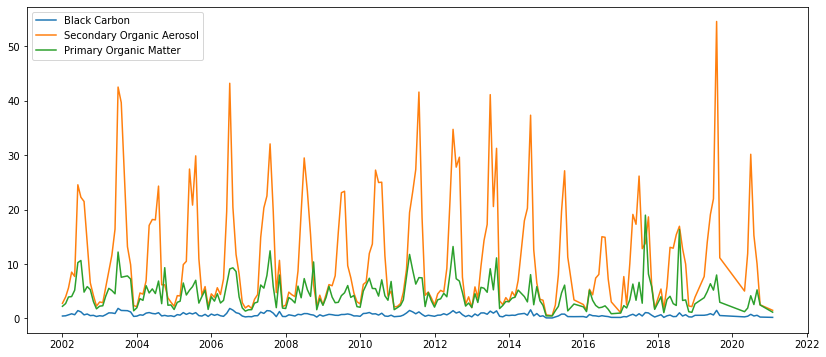

In [38]:
#Timeseries of DOC, BC, SOA, POM across all sites (means)
doc_monyr = df_clean_doc.groupby(['Year', 'Month'])['Mod_BC_mgm2', 'Mod_SOA_mgm2', 'Mod_POM_mgm2', 'BC_fraction', 'SOA_fraction','POM_fraction'].mean().reset_index()
doc_monyr['Yr-Mon'] = pd.to_datetime(doc_monyr[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(14, 6))
plt.plot(doc_monyr['Yr-Mon'], doc_monyr['Mod_BC_mgm2'], label = 'Black Carbon')
plt.plot(doc_monyr['Yr-Mon'], doc_monyr['Mod_SOA_mgm2'], label = 'Secondary Organic Aerosol')
plt.plot(doc_monyr['Yr-Mon'], doc_monyr['Mod_POM_mgm2'], label = 'Primary Organic Matter')
plt.legend()

<AxesSubplot:xlabel='Month', ylabel='BC_fraction'>

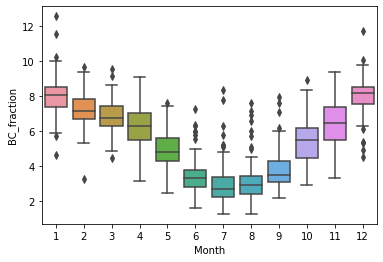

In [44]:
#Seasonality of each prop across all sites (monthly boxplots)
sns.boxplot(data = df_clean_doc, x = 'Month', y = 'BC_fraction')
#sns.boxplot(data = df_clean_doc, x = 'Month', y = 'SOA_fraction')
#sns.boxplot(data = df_clean_doc, x = 'Month', y = 'POM_fraction')


In [46]:
#site variability in DOC prop --> stacked barcharts w/ sites ordered longitudinally
doc_site = df_clean_doc.groupby(['siteId'])['Mod_BC_mgm2', 'Mod_SOA_mgm2', 'Mod_POM_mgm2', 'BC_fraction', 'SOA_fraction','POM_fraction'].mean().reset_index()
doc_site

/glade/derecho/scratch/demurray/tmp/ipykernel_33799/478224447.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  doc_site = df_clean_doc.groupby(['siteId'])['Mod_BC_mgm2', 'Mod_SOA_mgm2', 'Mod_POM_mgm2', 'BC_fraction', 'SOA_fraction','POM_fraction'].mean().reset_index()


,siteId,Mod_BC_mgm2,Mod_SOA_mgm2,Mod_POM_mgm2,BC_fraction,SOA_fraction,POM_fraction
0,AK02,0.020869,0.197829,0.090274,6.754267,64.028260,29.217471
1,AZ03,0.165900,2.721527,0.986364,6.044218,60.344117,33.611667
2,CA96,0.498320,12.029914,3.625391,3.084881,74.471906,22.443203
3,CO90,0.969225,11.360697,7.548010,5.415219,56.878158,37.706624
4,GA09,0.309421,7.146115,2.269651,3.937391,68.616344,27.446266
5,IA23,0.587434,11.426476,4.620136,4.177280,64.497054,31.325668
6,LA30,0.424120,6.151610,2.115231,5.540218,65.164749,29.295033
7,ME09,0.633570,10.051124,7.693933,4.329814,63.571289,32.098898
8,MN16,0.528637,6.261482,3.947816,5.218739,57.352070,37.429191
9,MN32,0.520395,9.063842,6.123073,5.108018,55.000303,39.891682
